In [1]:
import os
os.chdir("COST/genbenfun")

In [ ]:
from problem_base import Problem, SurrogateProblem
import numpy as np
import ioh

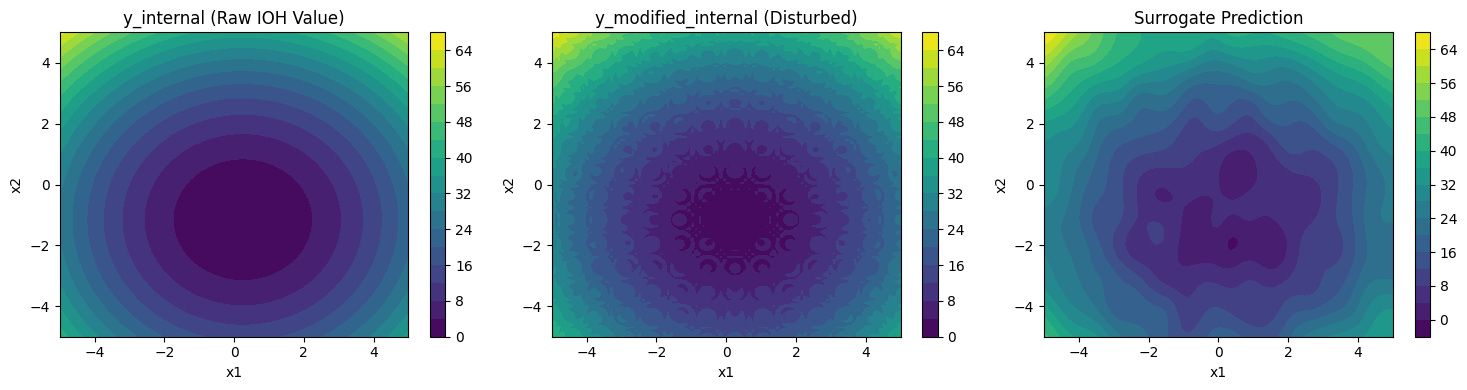

RMSE (vs raw y_internal): 1.839477
RMSE (vs disturbed y_modified_internal): 2.676690


In [7]:
import matplotlib.pyplot as plt

# Create a 2D SurrogateProblem and fit the surrogate
surr_prob_2d = SurrogateProblem(1, 1, 2, amplitude=0.5, frequency=0.5)
surr_prob_2d.create_surrogate(n_samples=150)

# Create a grid for evaluation
x1_range = np.linspace(-5, 5, 100)
x2_range = np.linspace(-5, 5, 100)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Store the three surfaces
Z_internal = np.zeros_like(X1)
Z_modified = np.zeros_like(X1)
Z_surrogate = np.zeros_like(X1)

# Evaluate at each grid point
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x = np.array([X1[i, j], X2[i, j]])
        
        # Get y_internal (raw internal value)
        y_internal_raw = surr_prob_2d.problem(x) - surr_prob_2d.problem.optimum.y
        Z_internal[i, j] = y_internal_raw
        
        # Get y_modified_internal (apply disturbance)
        Z_modified[i, j] = surr_prob_2d.apply_modification(x, y_internal_raw)
        
        # Get surrogate prediction
        Z_surrogate[i, j] = surr_prob_2d.evaluate_surrogate(x)

# Create 3 subplots with filled contours
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

contour1 = axes[0].contourf(X1, X2, Z_internal, levels=20, cmap='viridis')
axes[0].set_title('y_internal (Raw IOH Value)')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
plt.colorbar(contour1, ax=axes[0])

contour2 = axes[1].contourf(X1, X2, Z_modified, levels=20, cmap='viridis')
axes[1].set_title('y_modified_internal (Disturbed)')
axes[1].set_xlabel('x1')
axes[1].set_ylabel('x2')
plt.colorbar(contour2, ax=axes[1])

contour3 = axes[2].contourf(X1, X2, Z_surrogate, levels=20, cmap='viridis')
axes[2].set_title('Surrogate Prediction')
axes[2].set_xlabel('x1')
axes[2].set_ylabel('x2')
plt.colorbar(contour3, ax=axes[2])

plt.tight_layout()
plt.show()

# Evaluate model quality
rmse_true, rmse_disturbed = surr_prob_2d.evaluate_model_quality(n_samples=200)
print(f"RMSE (vs raw y_internal): {rmse_true:.6f}")
print(f"RMSE (vs disturbed y_modified_internal): {rmse_disturbed:.6f}")

In [5]:
import nevergrad as ng
from nevergrad.optimization.optimizerlib import (
    CMA,
    BFGS, 
    Cobyla, 
    PSO, 
    DE,
)

In [10]:
N_RUNS = 15
BUDGET = 2000

def run_experiment(fid, iid, dim, amp, freq, alg, version = 'surrogate'):
    surr_prob = SurrogateProblem(fid, iid, dim, amp, freq)
    surr_prob.create_surrogate()
    problem = surr_prob.get_problem(version=version)

    rmse_true, rmse_dist = surr_prob.evaluate_model_quality(1000)

    l = ioh.logger.Analyzer(algorithm_name=alg, folder_name=f"test_{fid}_{iid}_{dim}_{amp}_{freq}", root='.', triggers = [ioh.logger.trigger.ALWAYS],
    store_positions = True)
    l.add_experiment_attribute('version', version)
    l.add_experiment_attribute('rmse_true', f"{rmse_true}")
    l.add_experiment_attribute('rmse_dist', f"{rmse_dist}")

    l.watch(surr_prob, 'y_internal')
    l.watch(surr_prob, 'y_modified_internal')

    problem.attach_logger(l)

    for _ in range(N_RUNS):
        parametrization = ng.p.Array(shape=(problem.meta_data.n_variables,)).set_bounds(-5, 5)
        optimizer = eval(f"{alg}")(
            parametrization=parametrization, budget=int(BUDGET)
        )
        optimizer.minimize(problem)
        problem.reset()
    l.close()



In [11]:
run_experiment(1,1,2, 0.5,0.5, 'DE')